# Session 2: Deep Learning with Images, CIFAR-10, and Modern Vision Models

In this session we focus on **images**:

- Representing image data in PyTorch.
- Training and evaluating CNNs on CIFAR-10.
- Using **transfer learning** from pretrained models.
- Running a **YOLO** detector for object detection.

## 0. Setup

Import core libraries, pick a device (CPU or GPU), and set a random seed for reproducibility.

We will use:

- **PyTorch** and **torchvision** for models, training, and data.
- **Matplotlib** and **NumPy** for visualization and utilities.


In [ ]:
! pip install ultralytics grad-cam

In [1]:
%matplotlib inline

import random
import time
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models, utils as vutils

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

seed = 0
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 1. CIFAR-10 dataset

[CIFAR-10](https://www.cs.toronto.edu/~kriz/cifar.html) contains 60,000 color images of size **32×32×3** in 10 classes.

Here we will:

1. Set up transforms and load the train / test splits.
2. Build `DataLoader`.
3. Visualize a batch of images and class names.


In [2]:
cifar_root = Path("./data")

# Standard normalization for CIFAR-10 (per-channel mean and std)
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD = (0.2470, 0.2435, 0.2616)

train_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

train_dataset = datasets.CIFAR10(
    root=cifar_root,
    train=True,
    download=True,
    transform=train_transform,
)

test_dataset = datasets.CIFAR10(
    root=cifar_root,
    train=False,
    download=True,
    transform=test_transform,
)

classes = train_dataset.classes
print(f"Number of training images: {len(train_dataset)}")
print(f"Number of test images: {len(test_dataset)}")
print(f"Classes: {classes}")

Number of training images: 50000
Number of test images: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


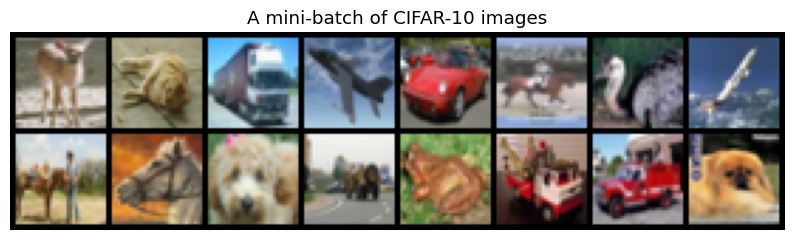

['deer', 'cat', 'truck', 'airplane', 'automobile', 'horse', 'bird', 'airplane', 'horse', 'horse', 'dog', 'truck', 'frog', 'truck', 'truck', 'dog']


In [3]:
batch_size = 128

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

# Grab a single batch for visualization
images, labels = next(iter(train_loader))

# Denormalize for plotting
inv_mean = torch.tensor(CIFAR10_MEAN).view(3, 1, 1)
inv_std = torch.tensor(CIFAR10_STD).view(3, 1, 1)

images_denorm = images * inv_std + inv_mean

grid = vutils.make_grid(images_denorm[:16], nrow=8, padding=2)
plt.figure(figsize=(10, 4))
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")
plt.title("A mini-batch of CIFAR-10 images")
plt.show()

print([classes[l] for l in labels[:16]])

## 2. Fully connected baseline

We first train a **multilayer perceptron (MLP)** that flattens each 32×32×3 image into a 3,072‑dimensional vector and predicts a CIFAR-10 class.

This model ignores spatial structure, so it will underperform compared to a CNN but gives a useful reference.


In [4]:
def accuracy_from_logits(logits, targets):
    preds = logits.argmax(dim=1)
    return (preds == targets).float().mean().item()


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    running_acc = 0.0
    num_batches = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        running_acc += accuracy_from_logits(outputs.detach(), labels)
        num_batches += 1

    return running_loss / num_batches, running_acc / num_batches


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_acc = 0.0
    num_batches = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            running_acc += accuracy_from_logits(outputs, labels)
            num_batches += 1

    return running_loss / num_batches, running_acc / num_batches

Epoch  1 | train loss 1.6422, train acc  42.1% | val loss 1.4910, val acc  46.4% | time  6.8s
Epoch  2 | train loss 1.4327, train acc  49.5% | val loss 1.4360, val acc  49.1% | time  5.9s
Epoch  3 | train loss 1.3161, train acc  53.6% | val loss 1.3885, val acc  51.4% | time  5.9s
Epoch  4 | train loss 1.2251, train acc  56.7% | val loss 1.3836, val acc  51.8% | time  5.9s
Epoch  5 | train loss 1.1443, train acc  59.4% | val loss 1.3936, val acc  52.2% | time  5.8s
Epoch  6 | train loss 1.0639, train acc  62.3% | val loss 1.4325, val acc  52.0% | time  6.0s


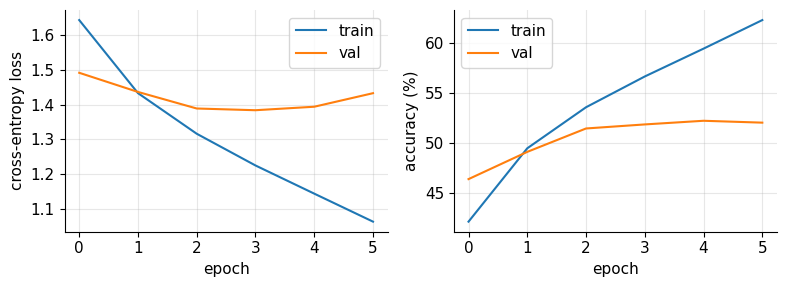

In [5]:
class MLPBaseline(nn.Module):
    def __init__(self, input_dim=32 * 32 * 3, hidden_dim=512, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, x):
        return self.net(x)


mlp = MLPBaseline().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(mlp.parameters(), lr=1e-3)

num_epochs_mlp = 6

train_losses, train_accs = [], []
val_losses, val_accs = [], []

for epoch in range(1, num_epochs_mlp + 1):
    t0 = time.time()
    train_loss, train_acc = train_one_epoch(mlp, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(mlp, test_loader, criterion, device)
    dt = time.time() - t0

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch {epoch:2d} | "
          f"train loss {train_loss:.4f}, train acc {train_acc*100:5.1f}% | "
          f"val loss {val_loss:.4f}, val acc {val_acc*100:5.1f}% | "
          f"time {dt:4.1f}s")

plt.figure(figsize=(8, 3))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label="train")
plt.plot(val_losses, label="val")
plt.xlabel("epoch")
plt.ylabel("cross-entropy loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot([a * 100 for a in train_accs], label="train")
plt.plot([a * 100 for a in val_accs], label="val")
plt.xlabel("epoch")
plt.ylabel("accuracy (%)")
plt.legend()
plt.tight_layout()
plt.show()

## 3. Convolutional neural network (CNN)

A CNN uses small learned kernels that slide over the image with shared weights and local connectivity.

We define a compact CNN for 32×32 images and train it with the same loop as before.


In [ ]:
class SmallCIFARCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 32x32 -> 16x16

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 16x16 -> 8x8

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 8x8 -> 4x4
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

Epoch  1 | train loss 1.4063, train acc  48.9% | val loss 1.1536, val acc  59.1% | time  7.6s
Epoch  2 | train loss 0.9842, train acc  65.3% | val loss 0.9018, val acc  68.5% | time  6.0s
Epoch  3 | train loss 0.7939, train acc  71.9% | val loss 0.8201, val acc  71.2% | time  6.1s
Epoch  4 | train loss 0.6708, train acc  76.5% | val loss 0.7502, val acc  74.1% | time  6.0s
Epoch  5 | train loss 0.5720, train acc  80.1% | val loss 0.7391, val acc  74.5% | time  6.1s
Epoch  6 | train loss 0.4776, train acc  83.3% | val loss 0.7188, val acc  75.8% | time  6.1s


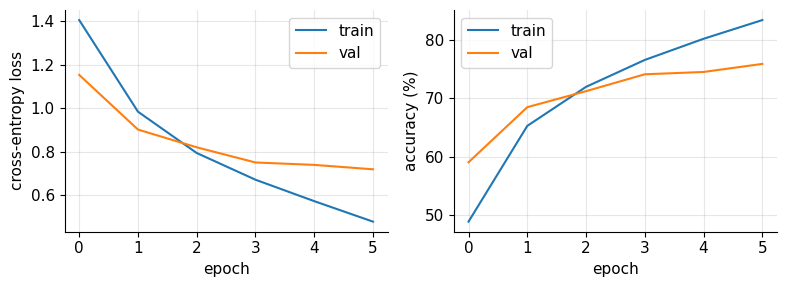

In [6]:
cnn = SmallCIFARCNN().to(device)
criterion_cnn = nn.CrossEntropyLoss()
optimizer_cnn = torch.optim.Adam(cnn.parameters(), lr=1e-3)

num_epochs_cnn = 6

train_losses_cnn, train_accs_cnn = [], []
val_losses_cnn, val_accs_cnn = [], []

for epoch in range(1, num_epochs_cnn + 1):
    t0 = time.time()
    train_loss, train_acc = train_one_epoch(cnn, train_loader, optimizer_cnn, criterion_cnn, device)
    val_loss, val_acc = evaluate(cnn, test_loader, criterion_cnn, device)
    dt = time.time() - t0

    train_losses_cnn.append(train_loss)
    train_accs_cnn.append(train_acc)
    val_losses_cnn.append(val_loss)
    val_accs_cnn.append(val_acc)

    print(f"Epoch {epoch:2d} | "
          f"train loss {train_loss:.4f}, train acc {train_acc*100:5.1f}% | "
          f"val loss {val_loss:.4f}, val acc {val_acc*100:5.1f}% | "
          f"time {dt:4.1f}s")

plt.figure(figsize=(8, 3))
plt.subplot(1, 2, 1)
plt.plot(train_losses_cnn, label="train")
plt.plot(val_losses_cnn, label="val")
plt.xlabel("epoch")
plt.ylabel("cross-entropy loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot([a * 100 for a in train_accs_cnn], label="train")
plt.plot([a * 100 for a in val_accs_cnn], label="val")
plt.xlabel("epoch")
plt.ylabel("accuracy (%)")
plt.legend()
plt.tight_layout()
plt.show()

## 5. Data augmentation and regularization

Data augmentation applies random transforms (flips, crops, color changes) to improve generalization.

We will:

1. Define an augmented transform pipeline for CIFAR-10.
2. Train a CNN with augmentation.
3. Compare validation accuracy to the non‑augmented model.


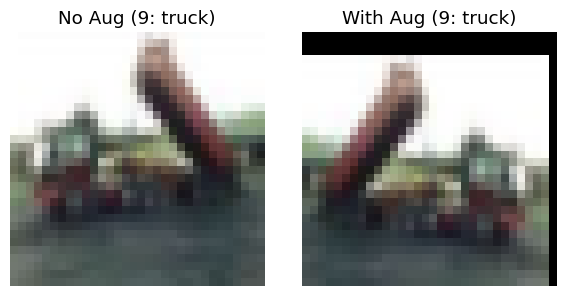

In [13]:
train_transform_no_aug = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

train_transform_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

# Datasets and loaders for both
train_dataset_no_aug = datasets.CIFAR10(
    root=cifar_root,
    train=True,
    download=False,
    transform=train_transform_no_aug,
)
train_loader_no_aug = DataLoader(train_dataset_no_aug, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)

train_dataset_aug = datasets.CIFAR10(
    root=cifar_root,
    train=True,
    download=False,
    transform=train_transform_aug,
)
train_loader_aug = DataLoader(train_dataset_aug, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
# Show one CIFAR-10 image without and with augmentation

# Get one sample from training dataset
img0, label0 = train_dataset_no_aug[2]
img1, label1 = train_dataset_aug[2]

# For visual display, denormalize images
def denormalize(img, mean, std):
    img = img.clone()
    for i in range(3):
        img[i] = img[i] * std[i] + mean[i]
    return img

img0_vis = denormalize(img0, CIFAR10_MEAN, CIFAR10_STD).permute(1, 2, 0).numpy()
img1_vis = denormalize(img1, CIFAR10_MEAN, CIFAR10_STD).permute(1, 2, 0).numpy()

plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plt.imshow(img0_vis)
plt.title(f"No Aug ({label0}: {classes[label0]})")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(img1_vis)
plt.title(f"With Aug ({label1}: {classes[label1]})")
plt.axis('off')
plt.tight_layout()
plt.show()

Epoch  1 | [No Aug] train_loss 1.3947, train_acc  49.3%, val_loss 1.0961, val_acc  60.6% | [Aug] train_loss 1.5804, train_acc  42.4%, val_loss 1.2278, val_acc  55.6% | time 15.5s
Epoch  2 | [No Aug] train_loss 0.9803, train_acc  65.1%, val_loss 0.8997, val_acc  68.3% | [Aug] train_loss 1.2094, train_acc  56.5%, val_loss 1.0270, val_acc  63.8% | time 15.2s
Epoch  3 | [No Aug] train_loss 0.7934, train_acc  72.3%, val_loss 0.8253, val_acc  71.3% | [Aug] train_loss 1.0192, train_acc  63.8%, val_loss 0.9134, val_acc  68.0% | time 15.0s
Epoch  4 | [No Aug] train_loss 0.6687, train_acc  76.4%, val_loss 0.7741, val_acc  73.5% | [Aug] train_loss 0.9063, train_acc  68.1%, val_loss 0.8014, val_acc  72.3% | time 15.0s
Epoch  5 | [No Aug] train_loss 0.5703, train_acc  79.9%, val_loss 0.7598, val_acc  74.0% | [Aug] train_loss 0.8267, train_acc  70.7%, val_loss 0.7388, val_acc  74.0% | time 14.9s
Epoch  6 | [No Aug] train_loss 0.4776, train_acc  83.2%, val_loss 0.7421, val_acc  75.8% | [Aug] train_lo

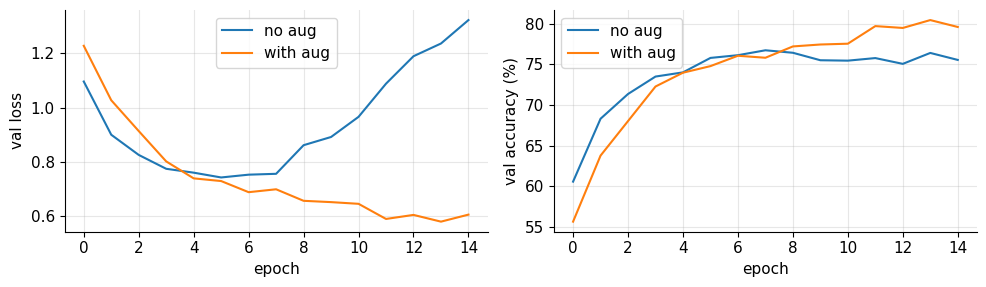

In [15]:
# Models, criteria, optimizers
cnn_no_aug = SmallCIFARCNN().to(device)
cnn_aug = SmallCIFARCNN().to(device)
criterion_no_aug = nn.CrossEntropyLoss()
criterion_aug = nn.CrossEntropyLoss()
optimizer_no_aug = torch.optim.Adam(cnn_no_aug.parameters(), lr=1e-3)
optimizer_aug = torch.optim.Adam(cnn_aug.parameters(), lr=1e-3)

num_epochs = 15

train_losses_no_aug, train_accs_no_aug = [], []
val_losses_no_aug, val_accs_no_aug = [], []
train_losses_aug, train_accs_aug = [], []
val_losses_aug, val_accs_aug = [], []

for epoch in range(1, num_epochs + 1):
    t0 = time.time()
    # Train with no augmentation
    train_loss_no_aug, train_acc_no_aug = train_one_epoch(cnn_no_aug, train_loader_no_aug, optimizer_no_aug, criterion_no_aug, device)
    val_loss_no_aug, val_acc_no_aug = evaluate(cnn_no_aug, test_loader, criterion_no_aug, device)

    train_losses_no_aug.append(train_loss_no_aug)
    train_accs_no_aug.append(train_acc_no_aug)
    val_losses_no_aug.append(val_loss_no_aug)
    val_accs_no_aug.append(val_acc_no_aug)

    # Train with augmentation
    train_loss_aug, train_acc_aug = train_one_epoch(cnn_aug, train_loader_aug, optimizer_aug, criterion_aug, device)
    val_loss_aug, val_acc_aug = evaluate(cnn_aug, test_loader, criterion_aug, device)

    train_losses_aug.append(train_loss_aug)
    train_accs_aug.append(train_acc_aug)
    val_losses_aug.append(val_loss_aug)
    val_accs_aug.append(val_acc_aug)

    dt = time.time() - t0

    print(f"Epoch {epoch:2d} | "
          f"[No Aug] train_loss {train_loss_no_aug:.4f}, train_acc {train_acc_no_aug*100:5.1f}%, val_loss {val_loss_no_aug:.4f}, val_acc {val_acc_no_aug*100:5.1f}% | "
          f"[Aug] train_loss {train_loss_aug:.4f}, train_acc {train_acc_aug*100:5.1f}%, val_loss {val_loss_aug:.4f}, val_acc {val_acc_aug*100:5.1f}% | "
          f"time {dt:4.1f}s")

plt.figure(figsize=(10, 3))
plt.subplot(1, 2, 1)
plt.plot(val_losses_no_aug, label="no aug")
plt.plot(val_losses_aug, label="with aug")
plt.xlabel("epoch")
plt.ylabel("val loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot([a * 100 for a in val_accs_no_aug], label="no aug")
plt.plot([a * 100 for a in val_accs_aug], label="with aug")
plt.xlabel("epoch")
plt.ylabel("val accuracy (%)")
plt.legend()
plt.tight_layout()
plt.show()

## 6. Transfer learning with ResNet-18

Instead of training a deep CNN from scratch, we start from a **ResNet-18** pretrained on ImageNet, replace the final layer, and fine‑tune it on CIFAR-10.


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/grads/sbd5760/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 118MB/s] 


[ResNet18] Epoch  1 | train loss 1.2567, train acc  61.0% | val loss 0.8985, val acc  71.3% | time 31.0s
[ResNet18] Epoch  2 | train loss 0.8077, train acc  74.0% | val loss 0.7748, val acc  74.5% | time 30.9s
[ResNet18] Epoch  3 | train loss 0.7292, train acc  75.8% | val loss 0.7238, val acc  75.4% | time 31.4s
[ResNet18] Epoch  4 | train loss 0.6848, train acc  76.7% | val loss 0.6977, val acc  76.2% | time 29.9s
[ResNet18] Epoch  5 | train loss 0.6610, train acc  77.4% | val loss 0.6862, val acc  76.5% | time 30.4s
[ResNet18] Epoch  6 | train loss 0.6418, train acc  78.1% | val loss 0.6930, val acc  76.1% | time 32.6s


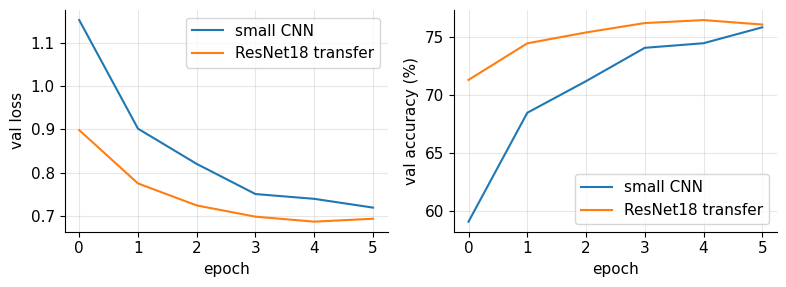

In [16]:
from torchvision.models import resnet18, ResNet18_Weights

# Transforms matching ImageNet pretraining
imagenet_weights = ResNet18_Weights.IMAGENET1K_V1
imagenet_transform = imagenet_weights.transforms()

train_dataset_imagenet = datasets.CIFAR10(
    root=cifar_root,
    train=True,
    download=False,
    transform=imagenet_transform,
)

test_dataset_imagenet = datasets.CIFAR10(
    root=cifar_root,
    train=False,
    download=False,
    transform=imagenet_transform,
)

# To keep training time manageable, optionally subsample the training set
subset_size = 20000
indices = torch.randperm(len(train_dataset_imagenet))[:subset_size]
train_subset = Subset(train_dataset_imagenet, indices)

train_loader_imagenet = DataLoader(train_subset, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)
test_loader_imagenet = DataLoader(test_dataset_imagenet, batch_size=128, shuffle=False, num_workers=2, pin_memory=True)

# Load pretrained ResNet-18 and adapt the final layer
resnet = resnet18(weights=imagenet_weights)
for param in resnet.parameters():
    param.requires_grad = False  # freeze backbone

num_features = resnet.fc.in_features
resnet.fc = nn.Linear(num_features, 10)  # CIFAR-10 has 10 classes

resnet = resnet.to(device)

criterion_resnet = nn.CrossEntropyLoss()
optimizer_resnet = torch.optim.Adam(resnet.fc.parameters(), lr=1e-3)

num_epochs_resnet = 6

train_losses_resnet, train_accs_resnet = [], []
val_losses_resnet, val_accs_resnet = [], []

for epoch in range(1, num_epochs_resnet + 1):
    t0 = time.time()
    train_loss, train_acc = train_one_epoch(resnet, train_loader_imagenet, optimizer_resnet, criterion_resnet, device)
    val_loss, val_acc = evaluate(resnet, test_loader_imagenet, criterion_resnet, device)
    dt = time.time() - t0

    train_losses_resnet.append(train_loss)
    train_accs_resnet.append(train_acc)
    val_losses_resnet.append(val_loss)
    val_accs_resnet.append(val_acc)

    print(f"[ResNet18] Epoch {epoch:2d} | "
          f"train loss {train_loss:.4f}, train acc {train_acc*100:5.1f}% | "
          f"val loss {val_loss:.4f}, val acc {val_acc*100:5.1f}% | "
          f"time {dt:4.1f}s")

plt.figure(figsize=(8, 3))
plt.subplot(1, 2, 1)
plt.plot(val_losses_cnn, label="small CNN")
plt.plot(val_losses_resnet, label="ResNet18 transfer")
plt.xlabel("epoch")
plt.ylabel("val loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot([a * 100 for a in val_accs_cnn], label="small CNN")
plt.plot([a * 100 for a in val_accs_resnet], label="ResNet18 transfer")
plt.xlabel("epoch")
plt.ylabel("val accuracy (%)")
plt.legend()
plt.tight_layout()
plt.show()

## 7. Grad-CAM: what the network looks at

**Grad-CAM** (Gradient-weighted Class Activation Mapping) is an interpretability method that shows *which regions* of the input image the model used to make its prediction. It works by:

1. **Forward pass**: Run the image through the network and get the logits for the target class.
2. **Gradients**: Backpropagate the target-class score to the last convolutional layer (here, `layer4` of a ResNet). The gradients indicate how much each spatial location in that feature map contributed to the score.
3. **Heatmap**: Combine those gradients with the feature-map activations (channel-wise) to get a single spatial map. After normalizing, this becomes the heatmap: warm (e.g. red) = more important for the prediction, cool (e.g. blue) = less important.

We run the image through **ImageNet-pretrained ResNet-50** model and display the original image next to the Grad-CAM heatmap. The input to the model must be passed *with* gradients enabled so that Grad-CAM can perform its backward pass.

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /home/grads/sbd5760/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 154MB/s] 


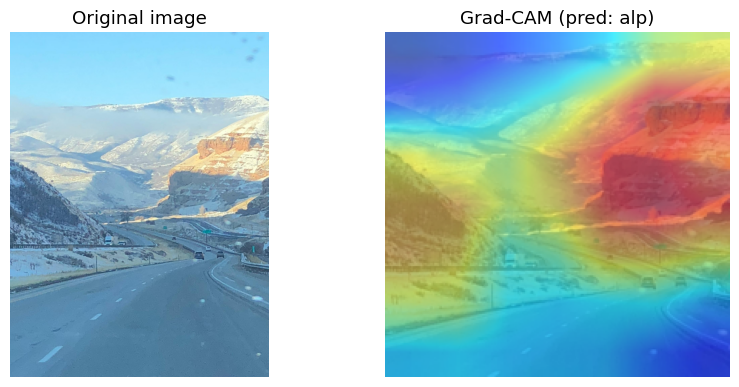

In [17]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
from PIL import Image
import requests
from io import BytesIO
from torchvision.models import resnet50, ResNet50_Weights

weights = ResNet50_Weights.IMAGENET1K_V1
cam_model = resnet50(weights=weights).to(device).eval()
imagenet_classes = weights.meta["categories"]
preprocess = weights.transforms()  # includes resize, center crop, normalization, etc.

# Fetch an image from the web
img_url = "https://images.pexels.com/photos/772891/pexels-photo-772891.jpeg"
response = requests.get(img_url, timeout=10)
image_pil = Image.open(BytesIO(response.content)).convert("RGB")

# Preprocess for ResNet-50 (ImageNet) and enable gradients
input_tensor = preprocess(image_pil).unsqueeze(0).to(device).requires_grad_(True)

# Forward pass and predicted class
logits = cam_model(input_tensor)
probs = logits.softmax(dim=1)
label = int(probs.argmax(dim=1).item())

cam = GradCAM(model=cam_model, target_layers=[cam_model.layer4[-1]])
targets = [ClassifierOutputTarget(label)]

# Grad-CAM needs gradients; do not use torch.no_grad() for the cam() call
grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

# Convert model input back to [0,1] for visualization (approximate)
input_np = input_tensor[0].detach().cpu().permute(1, 2, 0).numpy()
input_np = (input_np - input_np.min()) / (input_np.max() - input_np.min() + 1e-8)

cam_image = show_cam_on_image(input_np, grayscale_cam, use_rgb=True)

# Show original image and Grad-CAM heatmap side by side
plt.figure(figsize=(9, 4))
plt.subplot(1, 2, 1)
plt.imshow(image_pil)
plt.axis("off")
plt.title("Original image")

plt.subplot(1, 2, 2)
plt.imshow(cam_image)
plt.axis("off")
plt.title(f"Grad-CAM (pred: {imagenet_classes[label]})")

plt.tight_layout()
plt.show()


## 8. Object detection with YOLO

**Object detection** goes beyond classification: for each object in an image we predict a **bounding box** and a **class label**. Unlike CIFAR-10 (one label per image), a single image can contain many objects (people, cars, etc.), and the model must both localize and classify each.

**YOLO** (You Only Look Once) is a family of fast, single-stage detectors. YOLOv8 (from Ultralytics) is trained on **COCO** (Common Objects in Context), which has 80 classes (person, car, dog, etc.). The model outputs a set of boxes with class scores and post-processing that gives the final detections.

In this section we will:

1. Load the `ultralytics` YOLOv8 implementation and a pretrained checkpoint (`yolov8n.pt`, nano model).
2. Run inference on a sample image and visualize the predicted boxes and labels.
3. Inspect the number of detections and the COCO class names.



0: 640x480 4 persons, 1 bus, 1 stop sign, 46.5ms
Speed: 3.1ms preprocess, 46.5ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 480)


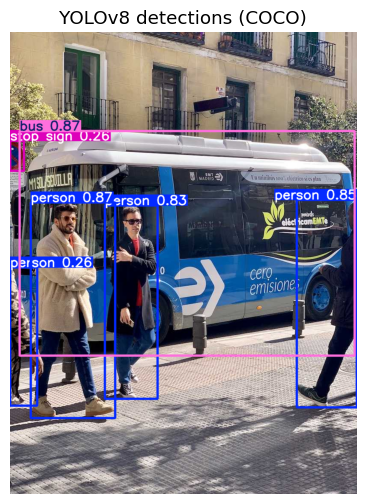

Detected classes: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 65: 'remote', 66: 'keyboard', 67: 'cell p

In [18]:
# Load a pretrained YOLOv8 model and run inference on a sample image

from PIL import Image
import requests
from io import BytesIO
from ultralytics import YOLO

# Small YOLO model pretrained on COCO (80 classes)
yolo_model = YOLO("yolov8n.pt")

# Use a sample image
img_url = "https://ultralytics.com/images/bus.jpg"
response = requests.get(img_url, timeout=10)
image_pil = Image.open(BytesIO(response.content)).convert("RGB")

results = yolo_model(image_pil)
result = results[0]

img_bgr = result.plot()
img_rgb = img_bgr[:, :, ::-1]

plt.figure(figsize=(8, 6))
plt.imshow(img_rgb)
plt.axis("off")
plt.title("YOLOv8 detections (COCO)")
plt.show()

print("Detected classes:", result.names)
print("Number of detections:", len(result.boxes))